# Wildfire Detection and Environmental Risk Analysis Using Geospatial Machine Learning

## Project Overview

Wildfires represent a major environmental and public safety challenge, particularly as climate patterns shift and fire seasons become longer and more severe. Satellite remote sensing systems provide continuous global monitoring of thermal activity, allowing researchers to detect active fires and analyze wildfire behavior at large geographic scales.

This project explores how machine learning and geospatial analysis can be used to study wildfire intensity patterns using satellite-derived wildfire detection data. By combining remote sensing measurements with spatial statistics, the analysis demonstrates how artificial intelligence techniques can support environmental monitoring and wildfire risk assessment.

The primary research question investigated in this project is:

**Can incorporating spatial relationships between wildfire detections improve the performance of machine learning models used to classify wildfire intensity?**

To answer this question, the project follows a structured workflow that includes data preprocessing, visualization of wildfire activity across the United States, baseline machine learning modeling, spatial autocorrelation analysis, and the development of a spatially informed machine learning model.

The results show that wildfire detections exhibit significant spatial clustering, and that incorporating spatial context into the model improves predictive performance. These findings highlight the potential value of combining machine learning with spatial analysis to better understand wildfire behavior and support environmental monitoring systems.

In [43]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from libpysal.weights import KNN, lag_spatial
from esda.moran import Moran

In [44]:
import seaborn as sns
from esda.moran import Moran
print("other packages loaded")

other packages loaded


## Dataset Description

This project uses a publicly available wildfire detection dataset derived from satellite observations. The dataset contains geographic coordinates and thermal measurements recorded by satellite sensors that monitor active fire activity across the United States.

Each observation in the dataset represents a satellite-detected fire pixel and includes both geographic and thermal attributes used to analyze wildfire behavior.

Key variables used in this analysis include:

- **latitude / longitude** – geographic coordinates of the detected wildfire location  
- **bright_ti4** – brightness temperature measured by the satellite’s thermal infrared sensor, reported in Kelvin. This value represents the thermal intensity of the detected fire signal.  
- **scan** – the width of the satellite scan footprint for the observation  
- **track** – the length of the satellite track footprint for the observation  
- **frp** – Fire Radiative Power, which measures the rate of energy released by the fire and is commonly used as an indicator of fire intensity

These variables provide both physical measurements of wildfire activity and observation geometry information from the satellite sensor. Together, they allow the dataset to be used for both geospatial visualization and machine learning analysis.

The dataset contains several thousand wildfire detections distributed across the contiguous United States, providing sufficient spatial coverage to analyze wildfire patterns and build predictive models.

In [45]:
fires = pd.read_csv("data/fires.csv")
fires.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,confidence,version,bright_ti5,frp,daynight
0,40.63617,-74.22680,295.57,0.34,0.56,2026-03-01,609,N20,nominal,2.0NRT,276.05,1.04,N
1,40.63594,-74.22276,299.14,0.34,0.56,2026-03-01,609,N20,nominal,2.0NRT,279.49,1.77,N
2,39.94313,-76.81786,312.52,0.46,0.63,2026-03-01,609,N20,nominal,2.0NRT,275.58,1.81,N
3,39.59225,-75.63779,300.63,0.39,0.59,2026-03-01,609,N20,nominal,2.0NRT,276.21,1.22,N
4,39.58675,-75.63825,297.74,0.39,0.59,2026-03-01,609,N20,nominal,2.0NRT,277.32,1.31,N


## Data Preparation and Geospatial Processing

Before performing spatial analysis and machine learning, the wildfire dataset must be prepared and converted into a format that supports geospatial operations.

The wildfire observations include latitude and longitude coordinates, which are used to convert the dataset into a **GeoDataFrame** using the GeoPandas library. This allows the wildfire detections to be treated as spatial points that can be mapped and analyzed geographically.

Next, a geographic boundary dataset containing the outlines of U.S. states is loaded. Because this project focuses only on the **contiguous United States**, Alaska, Hawaii, and Puerto Rico are removed from the state boundary dataset.

To ensure spatial operations work correctly, the coordinate reference system (CRS) of the state boundaries is aligned with the CRS of the wildfire GeoDataFrame.

Finally, a spatial join is performed to keep only wildfire detections that fall within the boundaries of the contiguous United States. This step removes detections outside the study region and prepares the dataset for visualization and spatial analysis in later sections.

In [46]:
# Load U.S. State Boundaries

states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

states.head()

# Convert Wildfire Data to GeoDataFrame

gdf = gpd.GeoDataFrame(
    fires,
    geometry=gpd.points_from_xy(fires.longitude, fires.latitude),
    crs="EPSG:4326"
)

gdf.head()

# remove Alaska, Hawaii, and Puerto Rico
states_conus = states[~states["name"].isin(["Alaska", "Hawaii", "Puerto Rico"])]

# make sure CRS matches
states_conus = states_conus.to_crs(gdf.crs)

# spatially filter wildfire detections to only those within the contiguous U.S.
fires_conus = gpd.sjoin(gdf, states_conus, predicate="within")

## Wildfire Detection Map

After preparing the geospatial dataset, the first step in the analysis is to visualize where wildfire detections occur across the contiguous United States.

Each wildfire detection is plotted as a point on the map using its latitude and longitude coordinates. The color of each point represents the **brightness temperature** recorded by the satellite sensor, which reflects the thermal intensity of the detected fire signal.

This visualization provides an initial overview of the geographic distribution of wildfire activity and helps identify areas where wildfire detections are more concentrated.

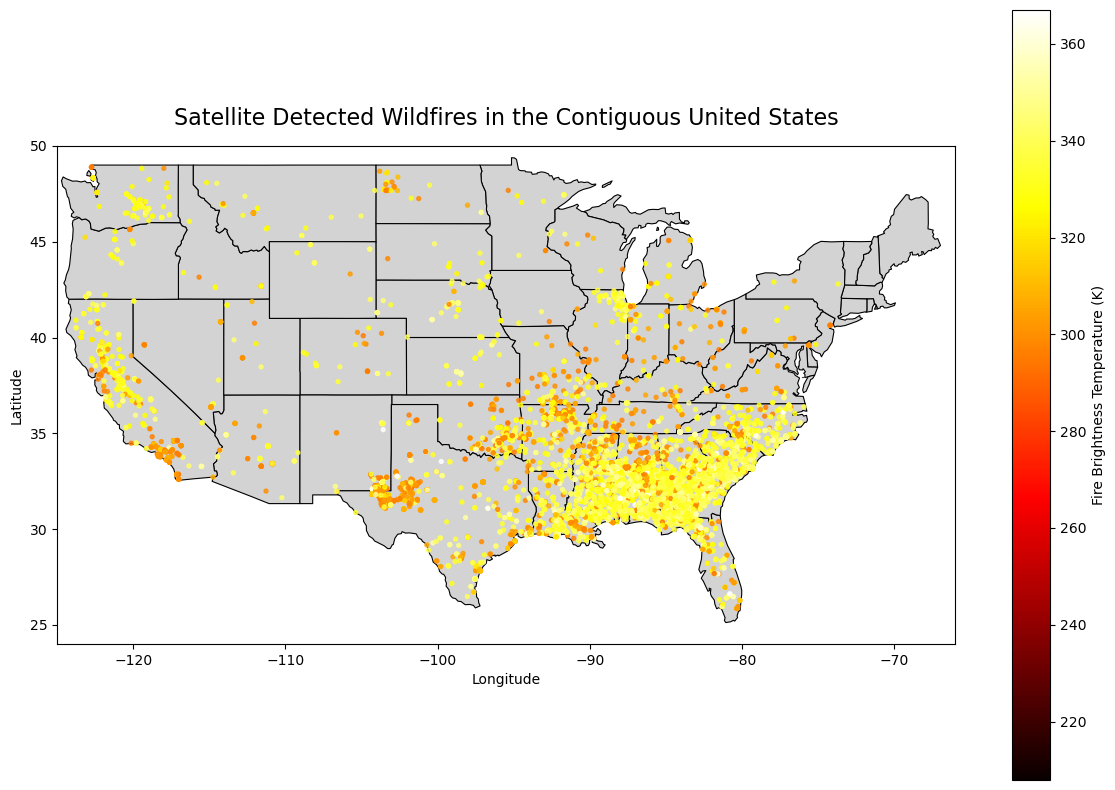

In [47]:
fig, ax = plt.subplots(figsize=(12,8))

# plot state boundaries
states_conus.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.8)

# plot wildfire detections
fires_conus.plot(
    ax=ax,
    column="bright_ti4",
    cmap="hot",
    markersize=8,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "label": "Fire Brightness Temperature (K)",
        "orientation": "vertical"
    }
)

# cleaner axis limits
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

# titles
ax.set_title(
    "Satellite Detected Wildfires in the Contiguous United States",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

plt.show()

### Interpretation

**Wildfire detections are heavily concentrated in the Southeastern United States, with additional clusters in parts of the western states.**

The wildfire detection map shows the geographic distribution of satellite-detected fire events across the contiguous United States. While wildfire detections appear throughout many regions, several areas show noticeably higher concentrations.

Large clusters of wildfire detections are visible in the **Southeastern United States**, particularly across Alabama, Georgia, Mississippi, and the Carolinas. Additional clusters appear in **California and parts of the western United States**, which are known for seasonal wildfire activity.

The color scale represents **fire brightness temperature**, where brighter colors indicate stronger thermal signals. These spatial patterns suggest that wildfire activity is not evenly distributed across the country and may exhibit regional clustering.

## Wildfire Density Heatmap

While the wildfire detection map shows the location of individual fire detections, it can be difficult to see broader geographic patterns when thousands of points are displayed at once.

To better visualize areas with repeated wildfire activity, a **density heatmap** is created using the wildfire detection locations. This type of visualization estimates the concentration of wildfire detections across geographic space by highlighting areas where many detections occur close together.

The heatmap helps reveal regional hotspots of wildfire activity and provides a clearer view of where wildfire detections are most concentrated across the contiguous United States.

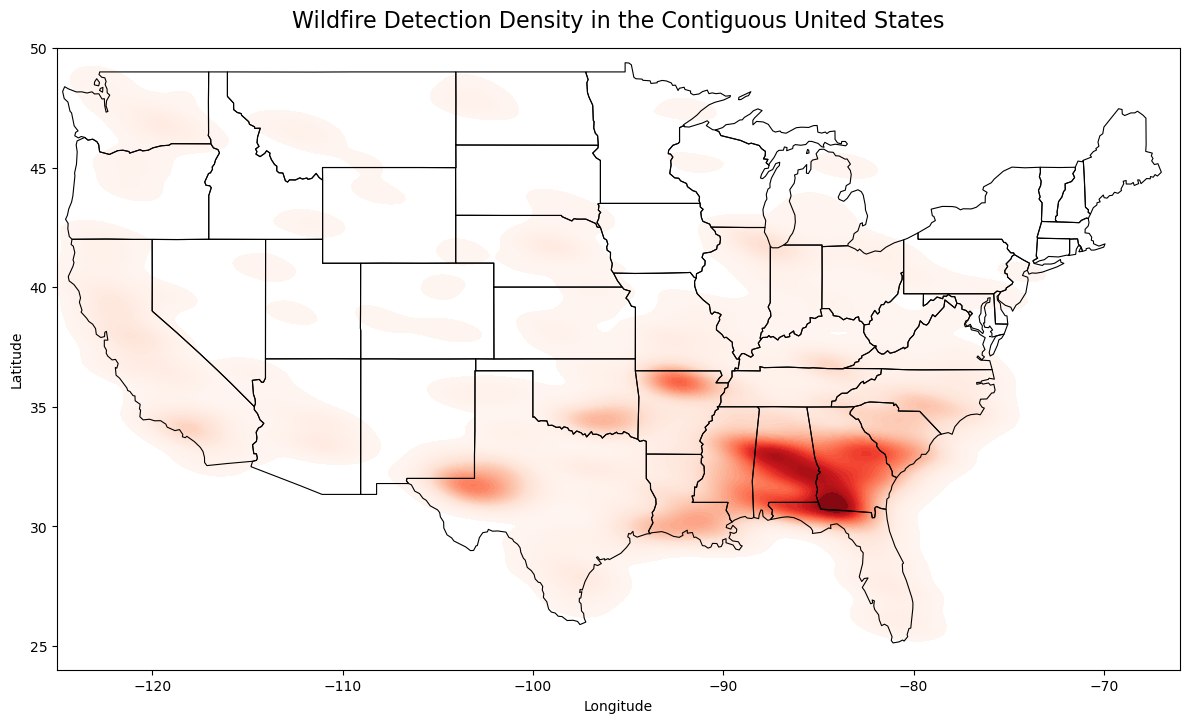

In [48]:
plt.figure(figsize=(12,8))
ax = plt.gca()

# Heatmap using only contiguous U.S. fire points
sns.kdeplot(
    x=fires_conus["longitude"],
    y=fires_conus["latitude"],
    fill=True,
    cmap="Reds",
    bw_adjust=0.5,
    levels=50,
    thresh=0.02,
    ax=ax
)

# Matching state boundaries from the fire map
states_conus.boundary.plot(ax=ax, linewidth=0.8, color="black")

# Match the fire map view
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title("Wildfire Detection Density in the Contiguous United States", fontsize=16, pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

### Interpretation

**Wildfire detections show strong geographic clustering, with the highest density concentrated in the Southeastern United States.**

The wildfire density heatmap highlights regions where wildfire detections occur most frequently. Unlike the individual detection map, this visualization emphasizes areas where many fire detections occur close together.

The highest concentration of wildfire detections appears in the **Southeastern United States**, particularly across Alabama, Georgia, Mississippi, and surrounding states. Smaller clusters are also visible in parts of **Texas and the western United States**, although these are less dense than the southeastern region.

These patterns suggest that wildfire activity is geographically clustered rather than randomly distributed. This observation motivates the use of spatial statistics in later sections to formally test whether wildfire detections exhibit spatial autocorrelation.

## Feature Engineering

Before training machine learning models, a target variable must be created to represent wildfire intensity levels.

In this project, wildfire detections are classified into two categories based on their **brightness temperature (`bright_ti4`)**. A binary variable called **`high_fire`** is created by comparing each observation to the median brightness temperature in the dataset.

Fires with brightness values **above the median** are labeled as **high-intensity fires**, while fires **below the median** are labeled as **lower-intensity fires**.

Using the median as the threshold helps create a **balanced classification problem**, where the two classes contain a similar number of observations. Balanced classes make it easier to evaluate machine learning models and avoid bias toward one class during training.

This engineered feature will serve as the **target variable** for the wildfire intensity classification models used later in the analysis.

In [49]:
fires_conus["high_fire"] = (
    fires_conus["bright_ti4"] > fires_conus["bright_ti4"].median()
).astype(int)

fires_conus["high_fire"].value_counts()

high_fire
0    4505
1    4496
Name: count, dtype: int64

### Interpretation

**The dataset produces a nearly balanced classification problem, which is ideal for training machine learning models.**

The class distribution shows that the number of **lower-intensity fires** and **higher-intensity fires** is nearly equal. This balance is expected because the classification threshold was defined using the median brightness temperature.

Balanced classes are beneficial for machine learning because they prevent the model from becoming biased toward predicting one class more frequently than the other. As a result, model performance metrics such as accuracy, precision, and recall can be interpreted more reliably.

## Correlation Matrix of Wildfire Variables

Before building the machine learning models, it is useful to examine how the wildfire variables relate to each other.

A correlation matrix is used to measure the strength of the linear relationship between variables in the dataset. Correlation values range from **-1 to 1**, where values closer to **1** indicate a strong positive relationship, values near **-1** indicate a strong negative relationship, and values near **0** indicate little to no linear relationship.

Understanding these relationships helps identify which variables may provide useful predictive information and whether any variables are highly correlated with one another.

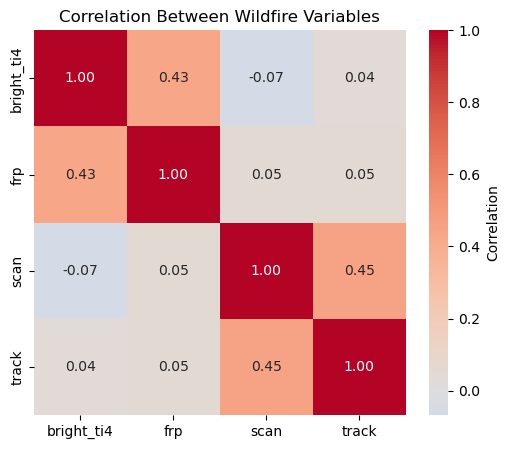

Correlation Table:


,bright_ti4,frp,scan,track
bright_ti4,1.00,0.43,-0.07,0.04
frp,0.43,1.00,0.05,0.05
scan,-0.07,0.05,1.00,0.45
track,0.04,0.05,0.45,1.00


In [64]:
import seaborn as sns

# Select variables used in modeling
corr_data = fires_conus[["bright_ti4", "frp", "scan", "track"]]

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Between Wildfire Variables")
plt.show()

# Display correlation table
print("Correlation Table:")
display(corr_matrix.round(2))

### Interpretation

**The strongest relationship in the dataset occurs between the satellite observation variables scan and track, while brightness temperature and Fire Radiative Power also show a strong positive relationship.**

The correlation matrix shows that **scan and track have the highest correlation (approximately 0.45)**. This relationship likely reflects how the satellite sensor records the size and shape of its observation footprint, since scan represents the width of the observation and track represents the length.

A moderate positive relationship is also visible between **brightness temperature (bright_ti4)** and **Fire Radiative Power (frp)** with a correlation of approximately **0.43**. This makes sense because both variables are related to the thermal intensity of wildfire activity.

Other relationships between variables are relatively weak, indicating that most features provide distinct information rather than duplicating the same measurement.

## Baseline Machine Learning Model

To evaluate whether wildfire intensity can be predicted using satellite observations, an initial baseline machine learning model is developed using a **Random Forest classifier**.

Random Forest models are commonly used for classification tasks because they can capture nonlinear relationships between variables and perform well with structured datasets. In this project, the model is trained to classify wildfire detections as either **lower-intensity** or **higher-intensity** fires based on satellite-derived features.

The initial feature set includes **brightness temperature (`bright_ti4`)**, **scan**, **track**, and **Fire Radiative Power (`frp`)**. This model serves as a starting point for evaluating wildfire intensity prediction before refining the feature set in later steps.

In [51]:
X = fires_conus[["bright_ti4", "scan", "track", "frp"]]

y = fires_conus["high_fire"]

X.head()

,bright_ti4,scan,track,frp
0,295.57,0.34,0.56,1.04
1,299.14,0.34,0.56,1.77
2,312.52,0.46,0.63,1.81
3,300.63,0.39,0.59,1.22
4,297.74,0.39,0.59,1.31


### Interpretation

**The initial baseline feature set includes both thermal and satellite observation variables that appear relevant for wildfire intensity classification.**

The selected features include **brightness temperature**, **scan**, **track**, and **Fire Radiative Power (FRP)**. Together, these variables capture both the thermal characteristics of the fire and properties of the satellite observation.

At this stage, the feature set appears reasonable for building an initial machine learning model. However, the next steps will evaluate whether all of these variables are appropriate for prediction and whether the model produces realistic results.

## Train-Test Split

Before training the machine learning model, the dataset is divided into **training** and **testing** sets. This allows the model to be evaluated on data it has not seen during training.

A **70/30 split** is used, where 70% of the observations are used to train the model and the remaining 30% are reserved for testing.

Using a separate testing dataset helps ensure that the model’s performance reflects how well it can **generalize to new wildfire detections**, rather than simply memorizing patterns from the training data.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 6300
Testing rows: 2701


### Interpretation

**The dataset is successfully divided into training and testing sets for model evaluation.**

The training dataset contains **6,300 wildfire observations**, which are used to train the Random Forest model. The testing dataset contains **2,701 observations**, which will be used to evaluate how well the model performs on unseen data.

## Baseline Model Training and Evaluation

After preparing the training and testing datasets, the Random Forest classifier is trained using the selected satellite observation features.

The model learns patterns from the **training dataset** and then generates predictions for the **testing dataset**. These predictions are compared with the true wildfire intensity labels to evaluate the model’s performance.

Model performance is measured using **accuracy, precision, recall, and F1-score**, which provide insight into how well the model correctly classifies wildfire intensity levels.

In [53]:
baseline_model = RandomForestClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds))

Baseline Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1382
           1       1.00      1.00      1.00      1319

    accuracy                           1.00      2701
   macro avg       1.00      1.00      1.00      2701
weighted avg       1.00      1.00      1.00      2701



### Interpretation

**The model reports perfect classification accuracy, which indicates that the feature set likely contains data leakage.**

The Random Forest model achieves **100% accuracy**, with perfect precision, recall, and F1-scores for both wildfire intensity classes. While this result may initially appear ideal, perfect performance is extremely rare in real-world machine learning problems.

This outcome suggests that one of the predictor variables may contain information that directly reveals the classification label. In other words, the model may be learning the answer rather than identifying meaningful predictive patterns.

To address this issue, the feature set will be adjusted in the next section to remove any variables that may be unintentionally leaking information about the target variable.

## Corrected Baseline Model

To eliminate the data leakage identified in the previous section, the feature set is adjusted by removing **brightness temperature (`bright_ti4`)** from the predictor variables.

This change is necessary because the wildfire intensity classification variable (**`high_fire`**) was created using the median value of `bright_ti4`. Including this variable in the model would allow the classifier to directly infer the target label, resulting in unrealistically perfect performance.

The corrected baseline model is therefore trained using the remaining satellite observation variables:

- **scan**
- **track**
- **frp**

These variables capture characteristics of the satellite observation and the fire’s energy output without directly revealing the classification threshold.

In [54]:
X = fires_conus[["scan", "track", "frp"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

baseline_model = RandomForestClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds))

Accuracy: 0.7845242502776749
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1382
           1       0.78      0.78      0.78      1319

    accuracy                           0.78      2701
   macro avg       0.78      0.78      0.78      2701
weighted avg       0.78      0.78      0.78      2701



### Interpretation

**After removing the leaking feature, the corrected baseline model achieves approximately 78% accuracy.**

The updated Random Forest model achieves an accuracy of about **78%**, with balanced precision and recall across both wildfire intensity classes.

This performance is much more realistic than the perfect accuracy observed earlier and provides a reliable **baseline benchmark** for wildfire intensity prediction using only satellite observation features.

This corrected baseline will be used as a reference when evaluating whether incorporating **spatial information** can improve model performance in later sections.

## Spatial Weights Matrix

To analyze spatial relationships between wildfire detections, a **spatial weights matrix** is created using a **k-nearest neighbors (KNN)** approach.

In this method, each wildfire detection is connected to its **five nearest neighboring detections** based on geographic distance. These neighbor relationships define how observations influence one another in spatial analysis.

The spatial weights matrix provides the structure needed to compute spatial statistics and to create spatial features that incorporate information from nearby wildfire detections.

In [55]:
coords = np.array(list(zip(fires_conus.geometry.x, fires_conus.geometry.y)))

w = KNN.from_array(coords, k=5)

w.transform = "r"

\\?\C:\Users\jordo\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 167 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


### Interpretation

**The spatial weights matrix successfully identifies neighboring wildfire detections, although the dataset forms several separate geographic clusters.**

The warning indicates that the spatial network is **not fully connected**, meaning wildfire detections are divided into multiple geographic groups rather than forming one continuous network.

This behavior is expected because wildfire activity occurs in **separate regions across the United States** rather than being evenly distributed across space. These disconnected components simply reflect the clustered nature of wildfire detections.

Despite this warning, the spatial weights matrix can still be used to compute spatial statistics and create spatial features for the machine learning model.

## Moran's I Spatial Autocorrelation

To formally evaluate whether wildfire detections are spatially clustered, **Moran’s I** is calculated using the wildfire brightness temperature values.

Moran’s I is a statistical measure of **spatial autocorrelation**, which describes whether nearby observations tend to have similar values. A positive Moran’s I value indicates that similar values cluster together geographically, while a value near zero suggests a random spatial distribution.

In this analysis, Moran’s I is computed using the wildfire brightness temperature (`bright_ti4`) and the spatial weights matrix created in the previous section.

In [56]:
moran = Moran(fires_conus["bright_ti4"], w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.515586395676015
p-value: 0.001


### Interpretation

**Wildfire detections exhibit strong and statistically significant spatial clustering.**

The calculated Moran’s I value of approximately **0.516** indicates a strong positive spatial relationship, meaning wildfire detections with similar brightness temperatures tend to occur near each other geographically.

The associated **p-value of 0.001** confirms that this clustering pattern is statistically significant and very unlikely to occur by random chance.

This result demonstrates that wildfire activity contains meaningful spatial structure. Because nearby wildfire detections are related to one another geographically, incorporating spatial information into the machine learning model may improve predictive performance.

## Spatial Feature Engineering

Since the previous section showed that wildfire detections exhibit significant spatial clustering, a new spatial feature is created to incorporate information from nearby fires.

Using the spatial weights matrix, a **spatial lag variable** called `neighbor brightness` is calculated. This variable represents the **average brightness temperature of neighboring wildfire detections**.

By including this feature, the model can consider not only the characteristics of a single fire detection but also the thermal activity of nearby fires. This helps incorporate **spatial context** into the machine learning model.

In [57]:
fires_conus["neighbor brightness"] = lag_spatial(w, fires_conus["bright_ti4"])

fires_conus[["bright_ti4", "neighbor brightness"]].head()

,bright_ti4,neighbor brightness
0,295.57,303.770
1,299.14,303.056
2,312.52,301.774
3,300.63,299.796
4,297.74,300.374


### Interpretation

**The new spatial feature captures the average brightness temperature of nearby wildfire detections.**

The `neighbor brightness` variable represents the spatial lag of wildfire brightness temperature. Each value reflects the average brightness temperature of the nearest neighboring fire detections based on the spatial weights matrix.

This confirms that spatial context has been successfully incorporated into the dataset. The next step is to include this spatial feature in the machine learning model to evaluate whether it improves wildfire intensity prediction.

## Spatial Machine Learning Model

To evaluate whether spatial context improves wildfire intensity prediction, the Random Forest model is retrained using the spatial feature created in the previous section.

In addition to the original satellite observation variables (**scan**, **track**, and **frp**), the model now includes the spatial lag variable **`neighbor brightness`**, which represents the average brightness temperature of nearby wildfire detections.

By incorporating this spatial feature, the model can account for geographic relationships between wildfire detections rather than relying only on local satellite measurements.

In [58]:
X_spatial = fires_conus[["scan", "track", "frp", "neighbor brightness"]]

y = fires_conus["high_fire"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_spatial, y, test_size=0.3, random_state=42
)

spatial_model = RandomForestClassifier(random_state=42)

spatial_model.fit(X_train_s, y_train_s)

spatial_preds = spatial_model.predict(X_test_s)

print("Spatial Model Accuracy:", accuracy_score(y_test_s, spatial_preds))
print(classification_report(y_test_s, spatial_preds))

Spatial Model Accuracy: 0.8211773417252869
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1382
           1       0.79      0.86      0.82      1319

    accuracy                           0.82      2701
   macro avg       0.82      0.82      0.82      2701
weighted avg       0.82      0.82      0.82      2701



### Interpretation

**Including spatial information improves model performance from approximately 78% to about 82% accuracy.**

After incorporating the spatial feature **`neighbor brightness`**, the Random Forest model achieves an accuracy of approximately **82%**, which is an improvement over the corrected baseline model that used only satellite observation variables.

The classification metrics also show balanced precision and recall across both wildfire intensity classes, indicating that the spatial model performs consistently when predicting both lower-intensity and higher-intensity fires.

This improvement suggests that wildfire behavior contains meaningful **spatial dependencies**, where nearby fire activity provides useful information for predicting wildfire intensity.

## Model Performance Comparison

To better illustrate the effect of incorporating spatial information, the performance of the **baseline model** and the **spatial machine learning model** are compared.

The baseline model uses only satellite observation features (**scan**, **track**, and **frp**), while the spatial model also includes the spatial lag feature **`neighbor brightness`**.

Comparing these models helps evaluate whether incorporating spatial relationships between wildfire detections improves predictive performance.

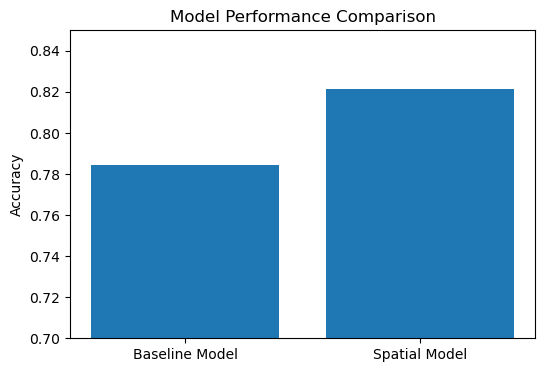

In [59]:
baseline_acc = 0.7845242502776749
spatial_acc = 0.8211773417252869

comparison = pd.DataFrame({
    "Model": ["Baseline Model", "Spatial Model"],
    "Accuracy": [baseline_acc, spatial_acc]
})

plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")

plt.ylim(0.7, 0.85)

plt.show()

### Interpretation

**The spatial wildfire model outperforms the baseline model after incorporating spatial information.**

The comparison chart shows that the baseline model achieves an accuracy of approximately **78%**, while the spatial model reaches about **82% accuracy** after including the **`neighbor brightness`** feature.

Although the improvement is modest, it demonstrates that incorporating spatial context provides additional predictive information beyond the original satellite observation variables.

This result supports the idea that wildfire activity is influenced by nearby fire conditions, and that combining **machine learning with spatial analysis** can improve wildfire modeling.

## Confusion Matrix

To better understand how the spatial machine learning model performs across the two wildfire intensity classes, a **confusion matrix** is generated.

A confusion matrix shows the number of correct and incorrect predictions made by the model by comparing the **true wildfire intensity labels** with the **predicted labels**.

This visualization helps identify where the model performs well and where misclassifications occur.

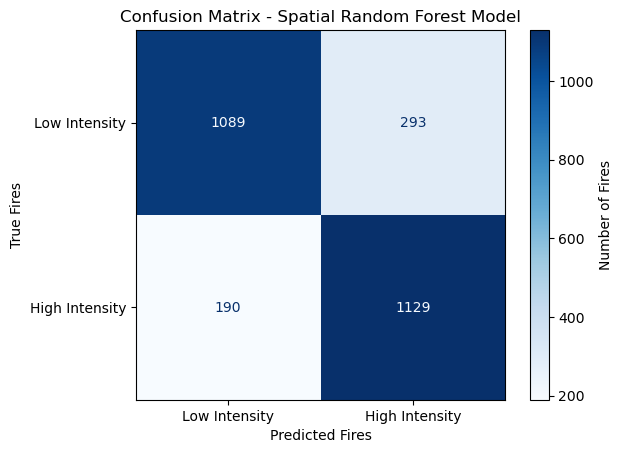

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_s, spatial_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Intensity", "High Intensity"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Spatial Random Forest Model")
plt.xlabel("Predicted Fires")
plt.ylabel("True Fires")

# Add label to colorbar
disp.im_.colorbar.set_label("Number of Fires")

plt.show()

### Interpretation

**The spatial model correctly classifies most wildfire detections while maintaining balanced performance across both intensity classes.**

The confusion matrix shows that the model correctly identifies **1,089 lower-intensity fires** and **1,129 higher-intensity fires**, demonstrating strong predictive performance for both categories.

Most classification errors occur when **lower-intensity fires are predicted as higher intensity (293 cases)** or when **higher-intensity fires are predicted as lower intensity (190 cases)**.

Despite these misclassifications, the model still achieves strong overall performance and maintains relatively balanced prediction accuracy across both wildfire intensity classes.

## ROC Curve

In addition to accuracy and the confusion matrix, a Receiver Operating Characteristic (ROC) curve is used to evaluate the performance of the spatial wildfire classification model.

The ROC curve measures how well the model distinguishes between the two wildfire intensity classes across different classification thresholds. It compares the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** as the decision threshold changes.

The **Area Under the Curve (AUC)** summarizes the overall performance of the classifier.  
An AUC value closer to 1 indicates strong model performance, while a value near 0.5 suggests performance similar to random guessing.

This visualization provides another perspective on the model’s ability to correctly classify wildfire intensity.

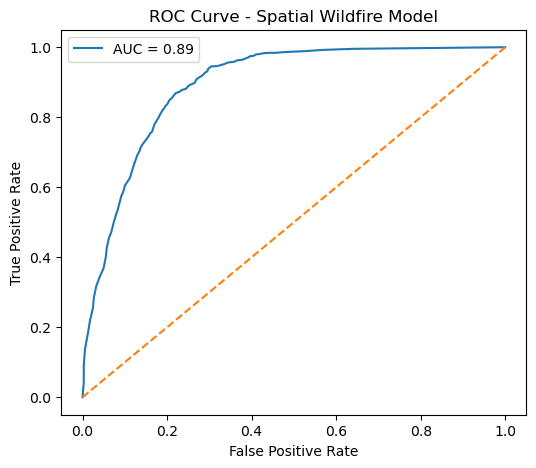

In [61]:
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities
y_probs = spatial_model.predict_proba(X_test_s)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_s, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve - Spatial Wildfire Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Interpretation

**The ROC curve shows that the spatial wildfire model has strong classification performance, with an AUC of approximately 0.89.**

The ROC curve rises quickly toward the top-left corner of the graph, which indicates that the model achieves a high true positive rate while maintaining a relatively low false positive rate.

An AUC value of 0.89 suggests that the model is able to effectively distinguish between lower-intensity and higher-intensity wildfire detections. In most cases, the classifier correctly ranks higher-intensity fires above lower-intensity fires.

These results further support the earlier evaluation metrics and confirm that the spatial machine learning model performs well when predicting wildfire intensity.

## Feature Importance

To better understand how the spatial machine learning model makes predictions, a **feature importance analysis** is performed using the trained Random Forest model.

Feature importance measures how much each input variable contributes to the model’s predictions. Higher importance values indicate that a variable plays a larger role in determining wildfire intensity classification.

The features analyzed include the satellite observation variables (**scan**, **track**, and **frp**) as well as the spatial lag feature **`neighbor brightness`**.

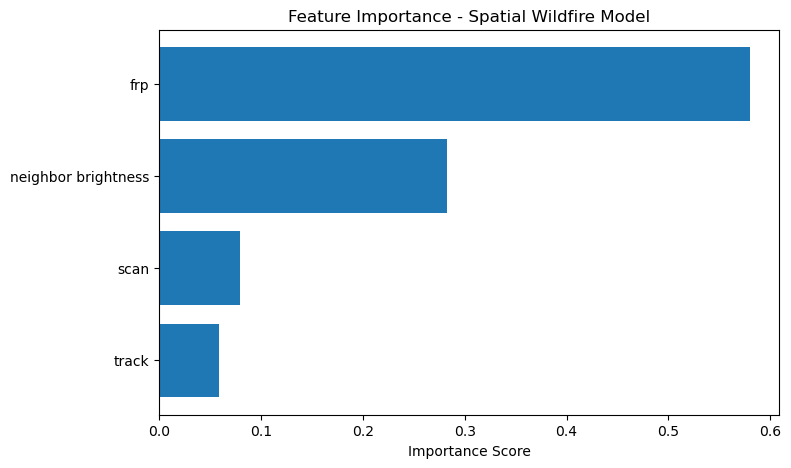

,Feature,Importance
2,frp,0.579653
3,neighbor brightness,0.282712
0,scan,0.079309
1,track,0.058326


In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance from spatial model
importance = spatial_model.feature_importances_
features = X_spatial.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance - Spatial Wildfire Model")
plt.xlabel("Importance Score")

plt.show()

importance_df

### Interpretation

**Fire Radiative Power (FRP) is the strongest predictor of wildfire intensity, while the spatial feature `neighbor brightness` is the second most important variable.**

The feature importance results show that **FRP contributes the most to the model’s predictions**, accounting for the largest share of the model’s decision-making. This is expected because FRP measures the amount of energy released by a fire and is closely related to fire intensity.

The spatial feature **`neighbor brightness`** is the second most important variable, indicating that nearby wildfire activity provides meaningful information for predicting fire intensity.

In comparison, the satellite observation geometry variables **scan** and **track** contribute much less to the model. These results demonstrate that both **physical fire measurements and spatial context** play important roles in wildfire prediction.

## Fire Brightness Distribution

To better understand the thermal characteristics of wildfire detections in the dataset, the distribution of **brightness temperature (`bright_ti4`)** is analyzed.

Brightness temperature represents the thermal signal detected by the satellite sensor and is reported in **Kelvin (K)**. Higher brightness temperatures generally correspond to more intense or actively burning fires.

A histogram is used to visualize how wildfire brightness temperatures are distributed across the dataset, and a percentage table summarizes the proportion of fires that fall within different temperature ranges.

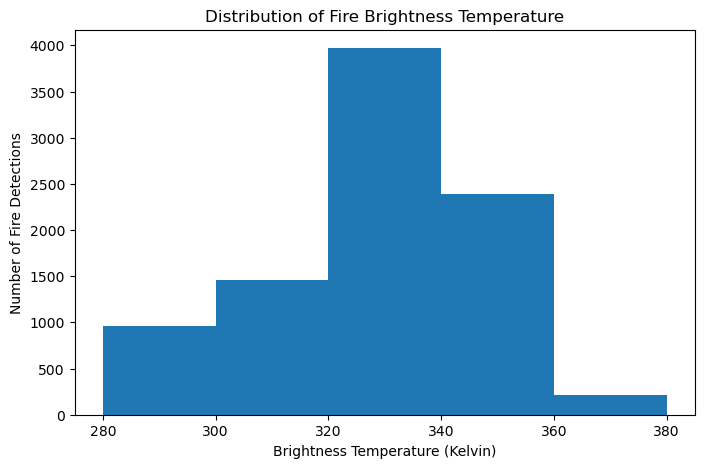

,Fire Count,Percentage (%)
brightness_range,,
"(280, 300]",964,10.71
"(300, 320]",1462,16.24
"(320, 340]",3973,44.14
"(340, 360]",2389,26.54
"(360, 380]",212,2.36


In [63]:
plt.figure(figsize=(8,5))

bins = [280, 300, 320, 340, 360, 380]

plt.hist(fires_conus["bright_ti4"], bins=bins)

plt.title("Distribution of Fire Brightness Temperature")
plt.xlabel("Brightness Temperature (Kelvin)")
plt.ylabel("Number of Fire Detections")

plt.show()

# Create brightness temperature ranges
bins = [280, 300, 320, 340, 360, 380]

fires_conus["brightness_range"] = pd.cut(
    fires_conus["bright_ti4"],
    bins=bins
)

# Count how many fires fall in each range
range_counts = fires_conus["brightness_range"].value_counts().sort_index()

# Convert to percentages
range_percent = (range_counts / len(fires_conus)) * 100

brightness_summary = pd.DataFrame({
    "Fire Count": range_counts,
    "Percentage (%)": range_percent.round(2)
})

brightness_summary

### Interpretation

**Most wildfire detections fall within the 320–340 K temperature range, indicating that moderate-to-high thermal intensity fires are most common in the dataset.**

The brightness temperature distribution shows that approximately **44% of wildfire detections occur between 320 K and 340 K**, making this the most common temperature range.

An additional **26.5% of detections fall between 340 K and 360 K**, representing stronger thermal signals associated with more intense fire activity. Lower brightness temperature detections below 300 K represent a much smaller proportion of the dataset.

These results indicate that most detected fires exhibit moderate to strong thermal signatures, which aligns with the satellite’s ability to detect actively burning wildfire regions.

## Limitations & Future Work

Although the spatial model improved predictive performance,
several limitations remain. The analysis uses a simplified
binary classification of wildfire intensity based on brightness
temperature. Future work could explore multi-class fire intensity
categories or incorporate additional environmental variables such
as vegetation, humidity, wind patterns, and seasonal climate data.

Additionally, more advanced spatial machine learning models,
including spatial regression or graph-based models, could further
capture geographic dependencies in wildfire behavior.

## Conclusion

This project investigated how machine learning and spatial analysis can be used to study wildfire intensity patterns using satellite-derived wildfire detection data.

Initial visualizations revealed clear geographic clustering of wildfire detections across the United States, particularly in the Southeastern region. A wildfire density heatmap further highlighted areas where fire detections occur most frequently.

A baseline Random Forest model was first developed using satellite observation features. After correcting for data leakage, the baseline model achieved an accuracy of approximately **78%**, demonstrating that satellite measurements such as **Fire Radiative Power (FRP)** contain useful information about wildfire intensity.

Spatial analysis using **Moran’s I** confirmed that wildfire detections exhibit strong spatial clustering, indicating that nearby fires tend to share similar intensity characteristics.

To incorporate this spatial structure into the model, a spatial feature called **`neighbor brightness`** was created to represent the average brightness temperature of nearby wildfire detections. Including this spatial feature improved the model’s accuracy to approximately **82%**.

Overall, the results show that incorporating spatial context can improve wildfire intensity prediction. This approach demonstrates the value of combining **machine learning with geospatial analysis** to better understand wildfire behavior and support environmental monitoring systems.